# Phase 2: 10-Class MNIST Classification — Logistic Regression (One-vs-Rest)
## Pipeline: Data Loading -> Preprocessing -> PCA -> Training -> CV Tuning -> Learning Curves -> Evaluation

## 1. Setup & Imports

In [1]:
import sys, os
sys.path.append('..')
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from ml_utils import train_test_split, StandardScaler
from ml_utils import classification_report, confusion_matrix
from ml_utils import compute_accuracy, k_fold_split, cross_validate
from ml_utils import plot_learning_curve, evaluate_model, show_misclassified
from sklearn.decomposition import PCA
from skimage.feature import hog
np.random.seed(42)
print("Libraries imported")

Libraries imported


## 2. Configuration

In [2]:
NUM_CLASSES = 10
TRAIN_SIZE, VAL_SIZE, TEST_SIZE = 0.70, 0.15, 0.15
PCA_VARIANCE = 0.95
K_FOLDS = 5
LC_FRACTIONS = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]
LR_GRID = [0.001, 0.01, 0.05]
ITER_GRID = [300, 500, 1000]
DEFAULT_LR = 0.01
DEFAULT_ITER = 500

## 3. Data Loading & Preprocessing

In [3]:
X_train_raw = np.load('../../mnist.npz/x_train.npy')
y_train_raw = np.load('../../mnist.npz/y_train.npy')
X_test_raw  = np.load('../../mnist.npz/x_test.npy')
y_test_raw  = np.load('../../mnist.npz/y_test.npy')
X_all = np.concatenate([X_train_raw, X_test_raw], axis=0)
y_all = np.concatenate([y_train_raw, y_test_raw], axis=0)

min_count = min(np.bincount(y_all))
balanced_idx = []
for c in range(NUM_CLASSES):
    c_idx = np.where(y_all == c)[0]
    np.random.shuffle(c_idx)
    balanced_idx.extend(c_idx[:min_count])
balanced_idx = np.array(balanced_idx)
np.random.shuffle(balanced_idx)
X_balanced, y_balanced = X_all[balanced_idx], y_all[balanced_idx]
X_norm = X_balanced / 255.0

X_temp, X_test, y_temp, y_test = train_test_split(
    X_norm, y_balanced, test_size=TEST_SIZE/(TRAIN_SIZE+VAL_SIZE+TEST_SIZE),
    random_state=42, stratify=y_balanced)
val_adj = VAL_SIZE / (TRAIN_SIZE + VAL_SIZE)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=val_adj, random_state=42, stratify=y_temp)
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Train: 44190, Val: 9470, Test: 9470


### Visualise Dataset Samples
One example per class from the training set.

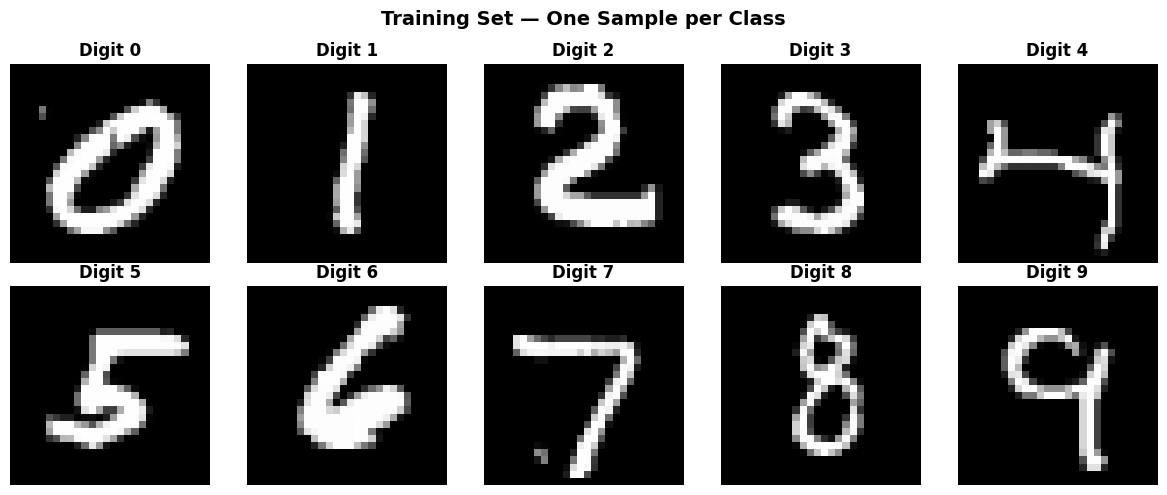

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for c in range(NUM_CLASSES):
    r, col = divmod(c, 5)
    idx = np.where(y_train == c)[0][0]
    axes[r, col].imshow(X_train[idx], cmap='gray')
    axes[r, col].set_title(f'Digit {c}', fontweight='bold')
    axes[r, col].axis('off')
plt.suptitle('Training Set — One Sample per Class', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4a. Flatten + Scaler + PCA Feature Extraction

In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_flat)
X_val_sc = scaler.transform(X_val_flat)
X_test_sc = scaler.transform(X_test_flat)
pca = PCA(n_components=PCA_VARIANCE, svd_solver='full')
X_train_pca = pca.fit_transform(X_train_sc)
X_val_pca = pca.transform(X_val_sc)
X_test_pca = pca.transform(X_test_sc)
print(f"PCA: {X_train_sc.shape[1]} → {X_train_pca.shape[1]} components ({np.sum(pca.explained_variance_ratio_):.4f} var)")

PCA: 784 → 324 components (0.9503 var)


### Visualise PCA

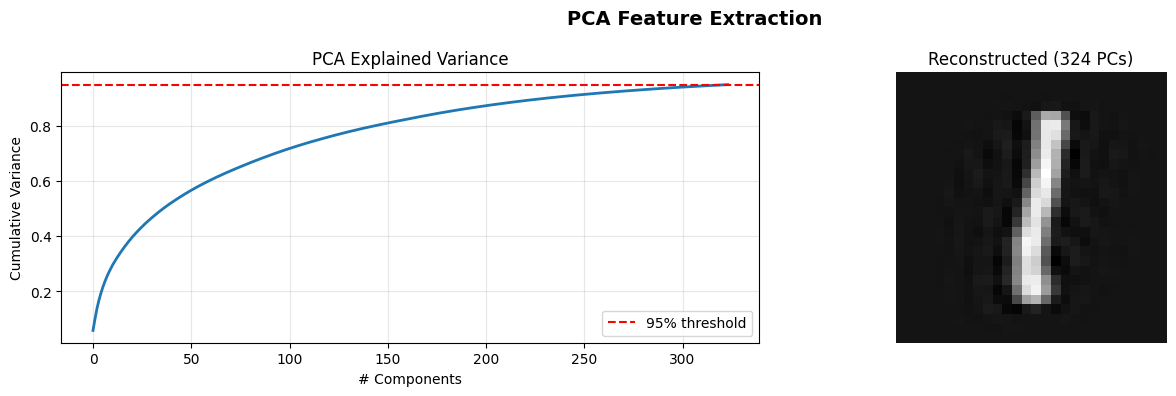

In [6]:
cum_var = np.cumsum(pca.explained_variance_ratio_)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(cum_var, linewidth=2)
axes[0].axhline(PCA_VARIANCE, ls='--', color='red', label=f'{PCA_VARIANCE:.0%} threshold')
axes[0].set_xlabel('# Components'); axes[0].set_ylabel('Cumulative Variance')
axes[0].set_title('PCA Explained Variance'); axes[0].legend(); axes[0].grid(alpha=.3)

recon = pca.inverse_transform(X_train_pca[0:1])
recon = scaler.inverse_transform(recon).reshape(28, 28)
axes[1].imshow(recon, cmap='gray')
axes[1].set_title(f'Reconstructed ({X_train_pca.shape[1]} PCs)'); axes[1].axis('off')
plt.suptitle('PCA Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 4b. HOG Feature Extraction

**Histogram of Oriented Gradients** captures edge and gradient structure.
Applied to the 2D images (before flattening), then standardised.

In [7]:
def extract_hog(images):
    feats = []
    for img in images:
        f = hog(img, orientations=9, pixels_per_cell=(4,4),
                cells_per_block=(2,2), block_norm='L2-Hys')
        feats.append(f)
    return np.array(feats)

X_train_hog = extract_hog(X_train)
X_val_hog   = extract_hog(X_val)
X_test_hog  = extract_hog(X_test)

scaler_hog = StandardScaler()
X_train_hog_sc = scaler_hog.fit_transform(X_train_hog)
X_val_hog_sc   = scaler_hog.transform(X_val_hog)
X_test_hog_sc  = scaler_hog.transform(X_test_hog)

print(f"HOG feature dim: {X_train_hog_sc.shape[1]}")
print("HOG features ready")

HOG feature dim: 1296
HOG features ready


### Visualise HOG Features

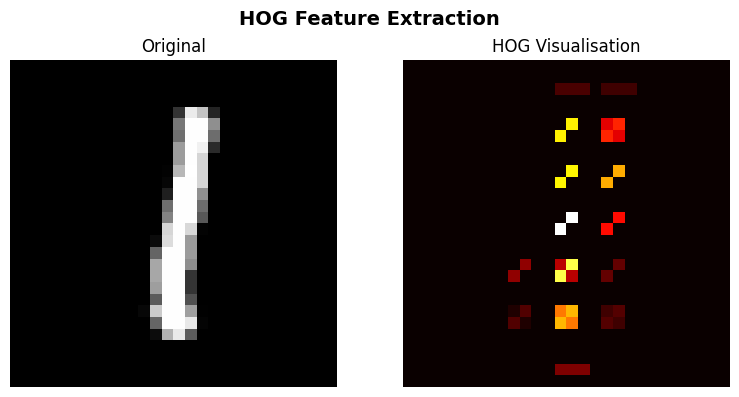

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(X_train[0], cmap='gray')
axes[0].set_title('Original'); axes[0].axis('off')
_, hog_img = hog(X_train[0], orientations=9, pixels_per_cell=(4,4),
                 cells_per_block=(2,2), block_norm='L2-Hys', visualize=True)
axes[1].imshow(hog_img, cmap='hot')
axes[1].set_title('HOG Visualisation'); axes[1].axis('off')
plt.suptitle('HOG Feature Extraction', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Logistic Regression Model (One-vs-Rest)

Uses **sigmoid** activation and **binary cross-entropy loss** per class.

In [9]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        self.lr = learning_rate
        self.n_iter = n_iterations
        self.models = []

    @staticmethod
    def _sigmoid(z):
        return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

    def fit(self, X, y):
        n, d = X.shape
        self.classes_ = np.unique(y)
        self.models = []
        for c in self.classes_:
            yb = (y == c).astype(float)
            w, b = np.zeros(d), 0.0
            for _ in range(self.n_iter):
                yh = self._sigmoid(X @ w + b)
                w -= self.lr * (X.T @ (yh - yb)) / n
                b -= self.lr * np.sum(yh - yb) / n
            self.models.append((w, b))
        return self

    def predict(self, X):
        scores = np.column_stack([self._sigmoid(X @ w + b) for w, b in self.models])
        return self.classes_[np.argmax(scores, axis=1)]

## 7. Baseline Training (PCA Features)

BASELINE LOGISTIC REGRESSION

LR Baseline — Test Acc: 0.8474 (84.74%)
                 precision     recall   f1-score    support

        Digit 0       0.86       0.96       0.91        947
        Digit 1       0.78       0.96       0.86        947
        Digit 2       0.88       0.79       0.83        947
        Digit 3       0.83       0.83       0.83        947
        Digit 4       0.86       0.90       0.88        947
        Digit 5       0.87       0.77       0.81        947
        Digit 6       0.87       0.92       0.89        947
        Digit 7       0.83       0.86       0.84        947
        Digit 8       0.85       0.73       0.79        947
        Digit 9       0.87       0.76       0.81        947

       accuracy                             0.85       9470
      macro avg       0.85       0.85       0.85       9470
   weighted avg       0.85       0.85       0.85       9470



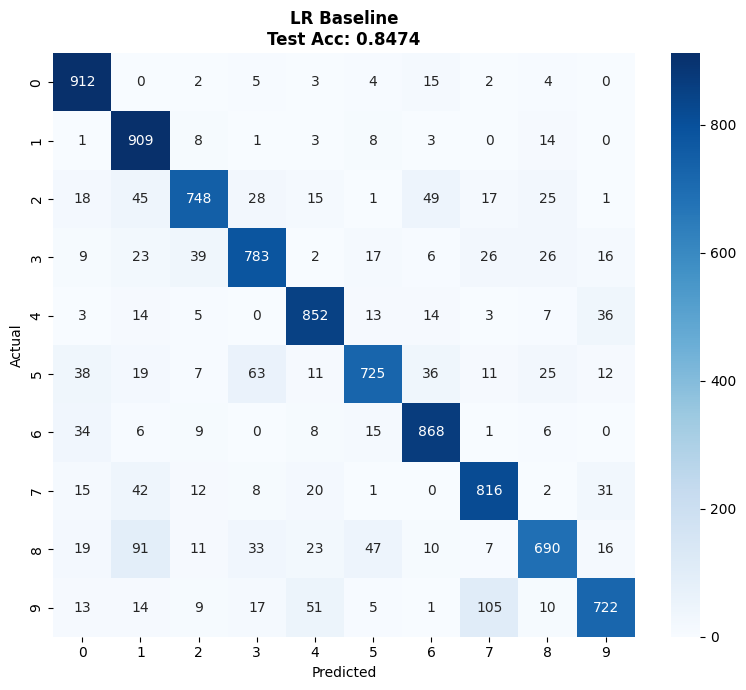

In [10]:
print("BASELINE LOGISTIC REGRESSION")
lr_base = LogisticRegression(learning_rate=DEFAULT_LR, n_iterations=DEFAULT_ITER)
lr_base.fit(X_train_pca, y_train)
base_acc = evaluate_model(lr_base, X_test_pca, y_test, "LR Baseline")

Misclassified: 1445 / 9470


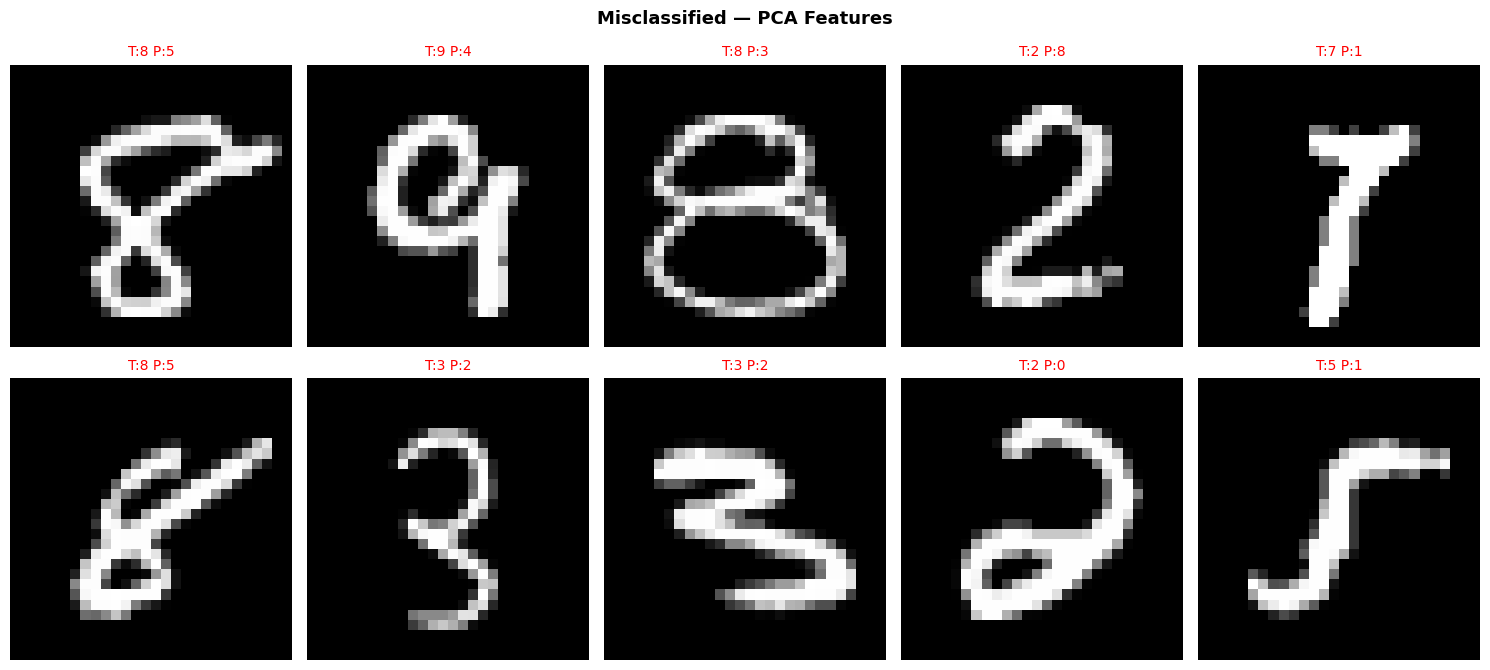

In [11]:
# Note: showing original images for misclassified PCA predictions
preds_pca = lr_base.predict(X_test_pca)
show_misclassified(y_test, preds_pca, X_test,
                   title='Misclassified — PCA Features')

### Logistic Regression — Flatten Features


Logistic Regression — Flatten Features

Logistic Regression (Flatten) — Test Acc: 0.8482 (84.82%)
                 precision     recall   f1-score    support

        Digit 0       0.86       0.96       0.91        947
        Digit 1       0.78       0.96       0.86        947
        Digit 2       0.88       0.79       0.83        947
        Digit 3       0.83       0.83       0.83        947
        Digit 4       0.86       0.90       0.88        947
        Digit 5       0.87       0.77       0.82        947
        Digit 6       0.87       0.92       0.89        947
        Digit 7       0.83       0.86       0.84        947
        Digit 8       0.85       0.73       0.79        947
        Digit 9       0.87       0.76       0.81        947

       accuracy                             0.85       9470
      macro avg       0.85       0.85       0.85       9470
   weighted avg       0.85       0.85       0.85       9470



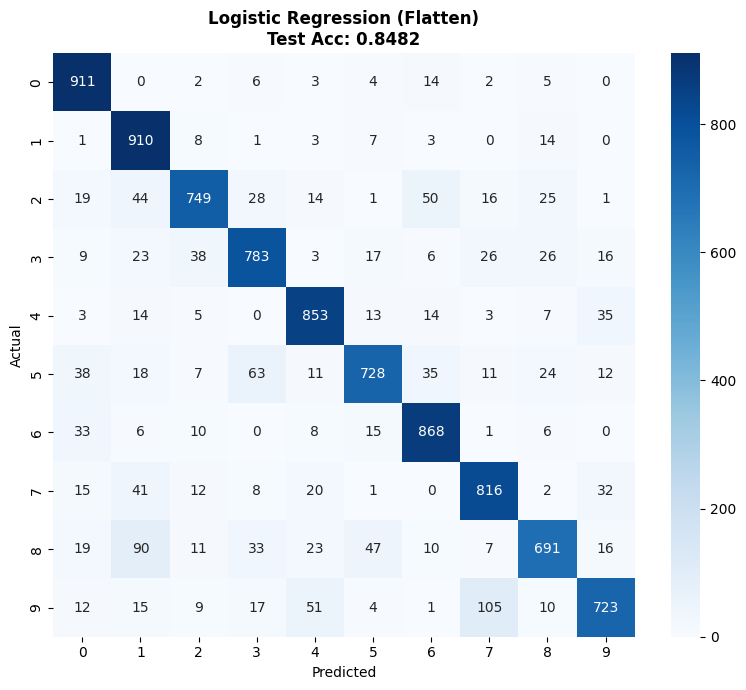

np.float64(0.8481520591341077)

In [12]:
print("\n" + "="*70)
print("Logistic Regression — Flatten Features")
print("="*70)
model_flatten = LogisticRegression(learning_rate=DEFAULT_LR, n_iterations=DEFAULT_ITER)
model_flatten.fit(X_train_sc, y_train)
evaluate_model(model_flatten, X_test_sc, y_test, "Logistic Regression (Flatten)")

Misclassified: 1438 / 9470


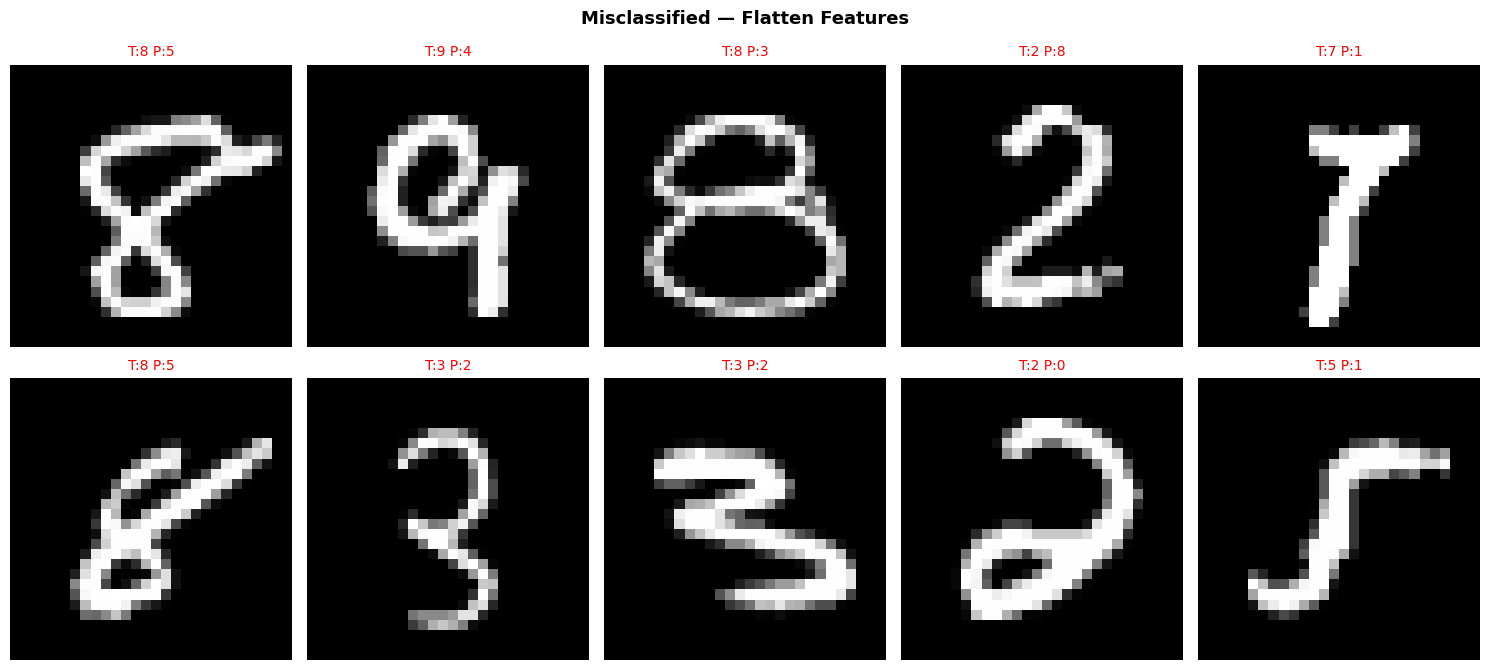

In [13]:
# Note: showing original images for misclassified Flatten predictions
preds_flatten = model_flatten.predict(X_test_sc)
show_misclassified(y_test, preds_flatten, X_test,
                   title='Misclassified — Flatten Features')

### Logistic Regression — HOG Features


Logistic Regression — HOG Features

Logistic Regression (HOG) — Test Acc: 0.9472 (94.72%)
                 precision     recall   f1-score    support

        Digit 0       0.94       0.97       0.96        947
        Digit 1       0.95       0.97       0.96        947
        Digit 2       0.93       0.95       0.94        947
        Digit 3       0.95       0.95       0.95        947
        Digit 4       0.96       0.95       0.96        947
        Digit 5       0.95       0.95       0.95        947
        Digit 6       0.92       0.96       0.94        947
        Digit 7       0.95       0.94       0.95        947
        Digit 8       0.97       0.89       0.93        947
        Digit 9       0.95       0.93       0.94        947

       accuracy                             0.95       9470
      macro avg       0.95       0.95       0.95       9470
   weighted avg       0.95       0.95       0.95       9470



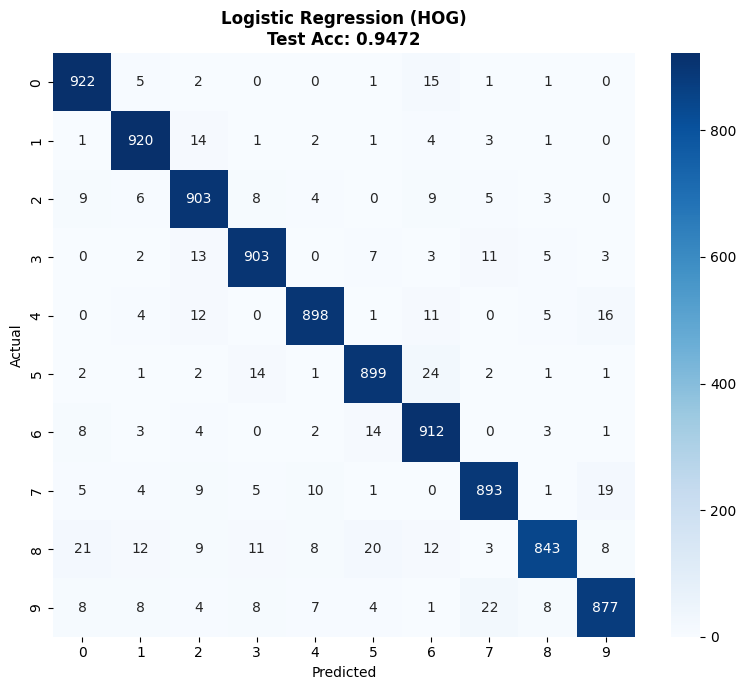

np.float64(0.9472016895459345)

In [14]:
print("\n" + "="*70)
print("Logistic Regression — HOG Features")
print("="*70)
model_hog = LogisticRegression(learning_rate=DEFAULT_LR, n_iterations=DEFAULT_ITER)
model_hog.fit(X_train_hog_sc, y_train)
evaluate_model(model_hog, X_test_hog_sc, y_test, "Logistic Regression (HOG)")

Misclassified: 500 / 9470


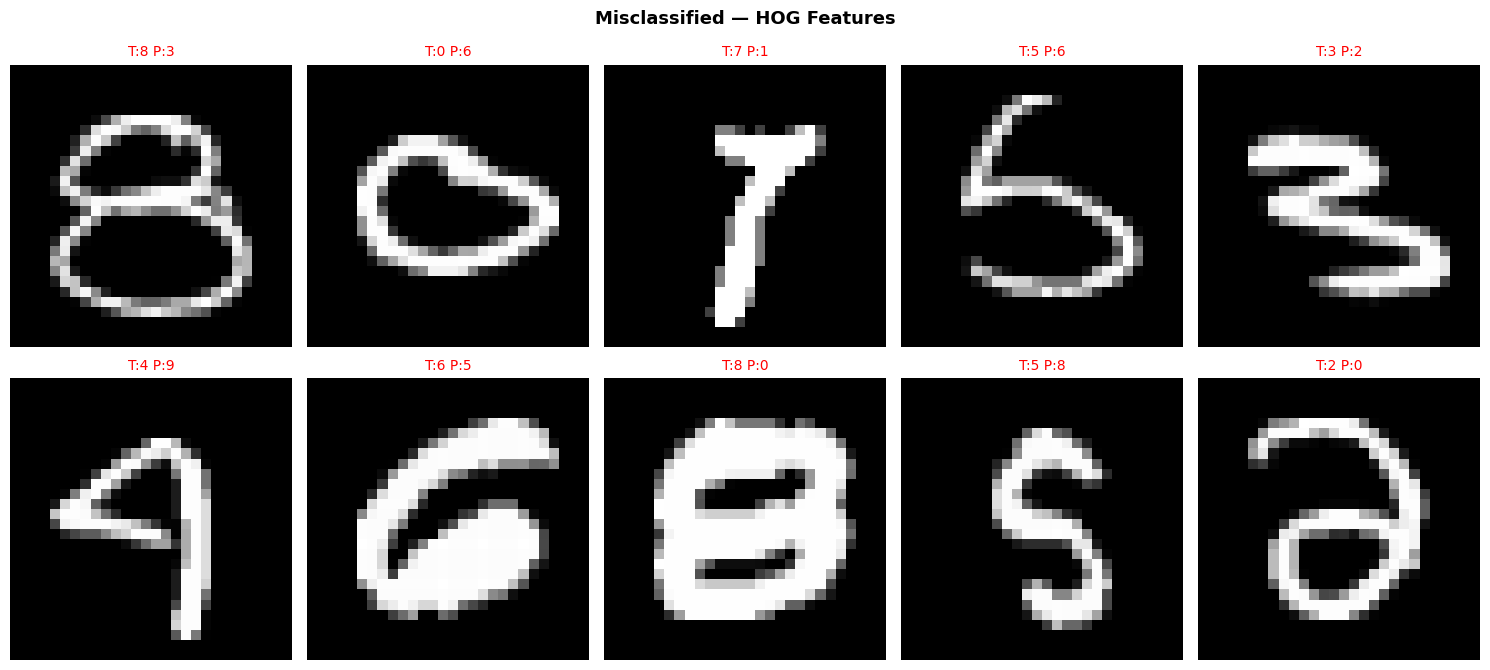

In [15]:
# Note: showing original images for misclassified HOG predictions
preds_hog = model_hog.predict(X_test_hog_sc)
show_misclassified(y_test, preds_hog, X_test,
                   title='Misclassified — HOG Features')

## 8. Hyperparameter Tuning (K-Fold CV)

In [16]:
best_acc, best_p = 0, {}
for lr in LR_GRID:
    for it in ITER_GRID:
        p = {'learning_rate': lr, 'n_iterations': it}
        print(f"\nLR={lr}, Iter={it}")
        a = cross_validate(LogisticRegression, p, X_train_pca, y_train, k=K_FOLDS)
        if a > best_acc: best_acc, best_p = a, p.copy()
print(f"\nBest: {best_p} (CV={best_acc:.4f})")


LR=0.001, Iter=300
  Fold 1/5: 0.8032
  Fold 2/5: 0.8093
  Fold 3/5: 0.8041
  Fold 4/5: 0.8052
  Fold 5/5: 0.8040
  Mean CV: 0.8052

LR=0.001, Iter=500
  Fold 1/5: 0.8167
  Fold 2/5: 0.8204
  Fold 3/5: 0.8170
  Fold 4/5: 0.8205
  Fold 5/5: 0.8151
  Mean CV: 0.8180

LR=0.001, Iter=1000
  Fold 1/5: 0.8301
  Fold 2/5: 0.8349
  Fold 3/5: 0.8306
  Fold 4/5: 0.8327
  Fold 5/5: 0.8284
  Mean CV: 0.8313

LR=0.01, Iter=300
  Fold 1/5: 0.8474
  Fold 2/5: 0.8499
  Fold 3/5: 0.8470
  Fold 4/5: 0.8474
  Fold 5/5: 0.8411
  Mean CV: 0.8465

LR=0.01, Iter=500
  Fold 1/5: 0.8549
  Fold 2/5: 0.8585
  Fold 3/5: 0.8549
  Fold 4/5: 0.8556
  Fold 5/5: 0.8475
  Mean CV: 0.8543

LR=0.01, Iter=1000
  Fold 1/5: 0.8671
  Fold 2/5: 0.8706
  Fold 3/5: 0.8659
  Fold 4/5: 0.8681
  Fold 5/5: 0.8585
  Mean CV: 0.8660

LR=0.05, Iter=300
  Fold 1/5: 0.8742
  Fold 2/5: 0.8763
  Fold 3/5: 0.8750
  Fold 4/5: 0.8746
  Fold 5/5: 0.8660
  Mean CV: 0.8732

LR=0.05, Iter=500
  Fold 1/5: 0.8828
  Fold 2/5: 0.8838
  Fold 3/5: 0.


LR Tuned — Test Acc: 0.8900 (89.00%)
                 precision     recall   f1-score    support

        Digit 0       0.93       0.97       0.95        947
        Digit 1       0.86       0.95       0.90        947
        Digit 2       0.90       0.86       0.88        947
        Digit 3       0.88       0.85       0.86        947
        Digit 4       0.88       0.92       0.90        947
        Digit 5       0.88       0.87       0.87        947
        Digit 6       0.91       0.93       0.92        947
        Digit 7       0.90       0.89       0.89        947
        Digit 8       0.88       0.82       0.85        947
        Digit 9       0.89       0.85       0.87        947

       accuracy                             0.89       9470
      macro avg       0.89       0.89       0.89       9470
   weighted avg       0.89       0.89       0.89       9470



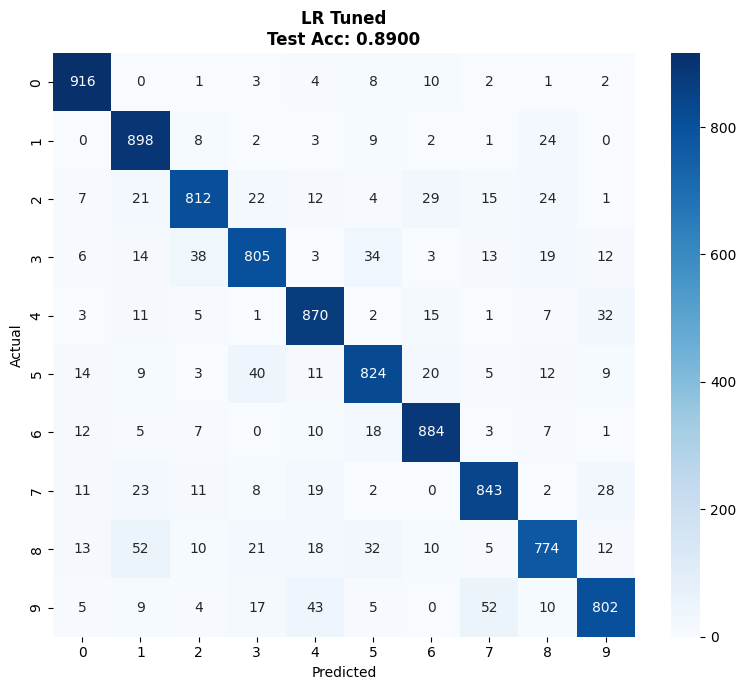

In [17]:
lr_tuned = LogisticRegression(**best_p)
lr_tuned.fit(X_train_pca, y_train)
tuned_acc = evaluate_model(lr_tuned, X_test_pca, y_test, "LR Tuned")

Misclassified: 1042 / 9470


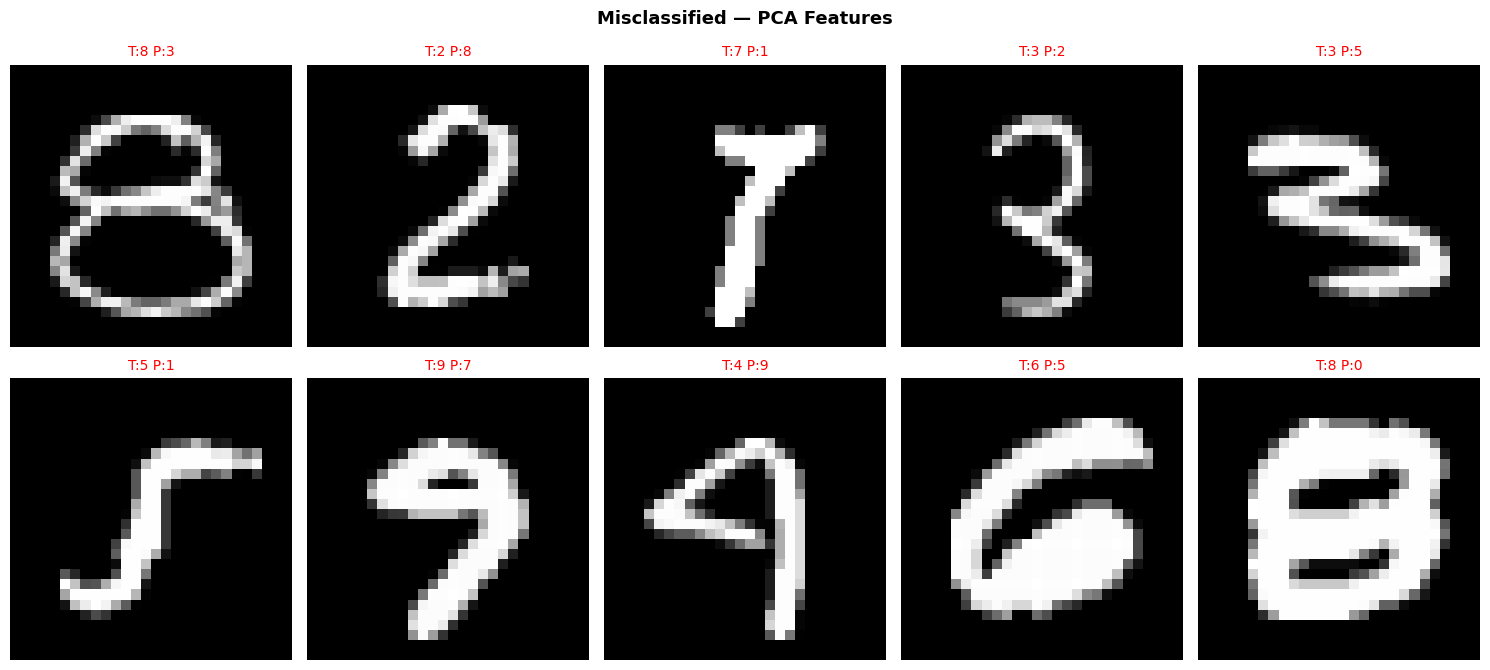

In [18]:
# Note: showing original images for misclassified PCA predictions
preds_pca = lr_tuned.predict(X_test_pca)
show_misclassified(y_test, preds_pca, X_test,
                   title='Misclassified — PCA Features')

## 9. Learning Curve

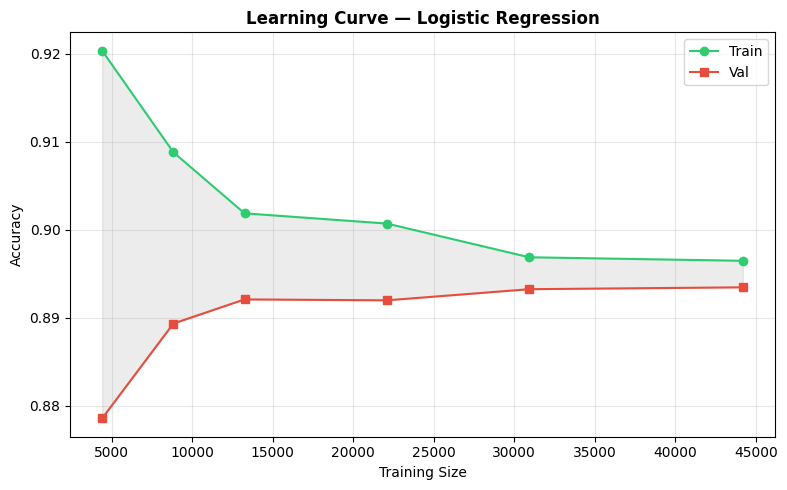

In [19]:
plot_learning_curve(LogisticRegression, best_p, X_train_pca, y_train,
                    X_val_pca, y_val, LC_FRACTIONS, "Learning Curve — Logistic Regression")

## 10. Summary
| Config | Test Accuracy |
|--------|-------------|
| Baseline | See above |
| Tuned (CV) | See above |

**Analysis**: If train & val curves converge at moderate accuracy → high bias (underfitting).
The linear OvR model may struggle with complex 10-class boundaries.